In [72]:
from Bio import pairwise2
from Bio.pairwise2 import format_alignment

def calculate_alignment_score(seq1, seq2):
    alignments = pairwise2.align.globalxx(seq1, seq2)
    # Use the best alignment
    best = alignments[0]
    identity = best[2] / best[4] * 100  # matches / aligned length * 100
    return identity


CENAFE = T59MS6 = 01.2025 run

EMPJFE = 2Q9KNT = 09.2023 run

JPEOAD = 8CQS4J = 03.2020 run

3 = reference genome

In [73]:
import pandas as pd
genome_df = pd.read_csv(
    '4way_ortholog_in_columns.csv',
    header=None,            # Don't treat the first row as column names
    # error_bad_lines=False,  # Skip lines with too many fields (deprecated but still functional in some versions)
    on_bad_lines='skip',    # For newer versions of pandas
    quoting=3,              # 3 means QUOTE_NONE: ignore quotes entirely
    engine='python'         # Use Python engine for better error recovery
)
genome_df.columns = [
    "01.2025_Locus", 
    "01.2025_Seq", 
    "03.2020_Locus",
    "03.2020_Seq",
    "09.2023_Locus", 
    "09.2023_Seq", 
    "Reference_Locus", 
    "Reference_Seq", 
]
# Filter out any rows where one of the sequences is completely missing
genome_df = genome_df[~genome_df['01.2025_Seq'].str.fullmatch('-+')]
genome_df = genome_df[~genome_df['03.2020_Seq'].str.fullmatch('-+')]
genome_df = genome_df[~genome_df['09.2023_Seq'].str.fullmatch('-+')]
genome_df = genome_df[~genome_df['Reference_Seq'].str.fullmatch('-+')]

genome_df


,01.2025_Locus,01.2025_Seq,03.2020_Locus,03.2020_Seq,09.2023_Locus,09.2023_Seq,Reference_Locus,Reference_Seq
0,0:24410-25264:CENAFE_00150 -,tcaggaaggttttttccctgtgcagtttcctccatccggccaaccg...,1:3760120-3760974:JPEOAD_03448 +,tcaggaaggttttttccctgtgcagtttcctccatccggccaaccg...,2:3804957-3805811:EMBJFE_03523 +,tcaggaaggttttttccctgtgcagtttcctccatccggccaaccg...,3,TCAGGAAGGTTTTTTCCCTGTGCAGTTTCCTCCATCCGGCCAACCG...
1,0:25274-25978:CENAFE_00155 -,tcacgtctcatcattagcgacatggtggttttggcggacaatctgc...,1:3759406-3760110:JPEOAD_03447 +,tcacgtctcatcattagcgacatggtggttttggcggacaatctgc...,2:3804243-3804947:EMBJFE_03522 +,tcacgtctcatcattagcgacatggtggttttggcggacaatctgc...,3,TCACGTCTCATCATTAGCGACATGGTGGTTTTGGCGGACAATCTGC...
2,0:25975-26670:CENAFE_00160 -,tcatgctcttgcctccacatgatccttgcctgaatagccagtacac...,1:3758714-3759409:JPEOAD_03446 +,tcatgctcttgcctccacatgatccttgcctgaatagccagtacac...,2:3803551-3804246:EMBJFE_03521 +,tcatgctcttgcctccacatgatccttgcctgaatagccagtacac...,3,TCATGCTCTTGCCTCCACATGATCCTTGCCTGAATAGCCAGTACAC...
3,0:26673-28205:CENAFE_00165 -,ttatccccctttcaccgtatgacgacgaatttccggtcttacaccc...,1:3757179-3758711:JPEOAD_03445 +,ttatccccctttcaccgtatgacgacgaatttccggtcttacaccc...,2:3802016-3803548:EMBJFE_03520 +,ttatccccctttcaccgtatgacgacgaatttccggtcttacaccc...,3,TTATCCCCCTTTCACCGTATGACGACGAATTTCCGGTCTTACACCC...
4,0:28258-29793:CENAFE_00170 -,tcatcccttccctttttcggtggtgtcaaaccagttcacatcgttc...,1:3755591-3757126:JPEOAD_03444 +,tcatcccttccctttttcggtggtgtcaaaccagttcacatcgttc...,2:3800428-3801963:EMBJFE_03519 +,tcatcccttccctttttcggtggtgtcaaaccagttcacatcgttc...,3,TCATCCCTTCCCTTTTTCGGTGGTGTCAAACCAGTTCACATCGTTC...
...,...,...,...,...,...,...,...,...
3349,0:1680011-1680175:CENAFE_07915 +,atgctgaatatcgagttgcggtattgcgcgcggcttcaggatgctg...,1,atgctgaatatcgagttgcggtattgcgcgcggcttcaggatgctg...,2:976868-977032:EMBJFE_00865 -,atgctgaatatcgagttgcggtattgcgcgcggcttcaggatgctg...,3,ATGCTGAATATCGAGTTGCGGTATTGCGCGCGGCTTCAGGATGCTG...
3350,0:2226182-2226565:CENAFE_10375 +,atgaaatacacgaaagcatggactgtggcttttgttgccatggcac...,1,atgaaatacacgaaagcatggactgtggcttttgttgccatggcac...,2:430465-430848:EMBJFE_00376 -,atgaaatacacgaaagcatggactgtggcttttgttgccatggcac...,3,ATGAAATACACGAAAGCATGGACTGTGGCTTTTGTTGCCATGGCAC...
3352,0:3390620-3390847:CENAFE_15610 -,ttaaaaattagtgccgagtgatcggggatcagatttaatgaaccct...,1,ttaaaaattagtgccgagtgatcggggatcagatttaatgaaccct...,2:2843915-2844142:EMBJFE_02605 +,ttaaaaattagtgccgagtgatcggggatcagatttaatgaaccct...,3,TTAAAAATTAGTGCCGAGTGATCGGGGATCAGATTTAATGAACCCT...
3356,0:3624373-3625119:CENAFE_16720 -,tcaggcaggtagcgtgtccatggcgctgcgcacggccggatagagc...,1,tcaggcaggtagcgtgtccatggcgctgcgcacggccggatagagc...,2:2609488-2610234:EMBJFE_02384 +,tcaggcaggtagcgtgtccatggcgctgcgcacggccggatagagc...,3,TCAGGCAGGTAGCGTGTCCATGGCGCTGCGCACGGCCGGATAGAGC...


In [74]:
from tqdm import tqdm

def calculate_num_mutations_per_gene(col1, col2):
    num_mutations = []

    for i, row in tqdm(genome_df.iterrows(), total=len(genome_df)):
        seq1 = row[col1].lower()
        seq2 = row[col2].lower()

        # Handle bad or missing data
        if not isinstance(seq1, str) or not isinstance(seq2, str):
            num_mutations.append(None)
            continue
        if len(seq1) != len(seq2):
            num_mutations.append(None)
            continue

        matches = sum(a == b for a, b in zip(seq1, seq2))
        # mutational edits
        score = len(seq1) -  matches 
        num_mutations.append(score)
    return num_mutations


# Add result to DataFrame
genome_df['01.2025<>03.2020'] = calculate_num_mutations_per_gene('01.2025_Seq', '03.2020_Seq')
genome_df['01.2025<>09.2023'] = calculate_num_mutations_per_gene('01.2025_Seq', '09.2023_Seq')
genome_df['01.2025<>Reference'] = calculate_num_mutations_per_gene('01.2025_Seq', 'Reference_Seq')
genome_df['03.2020<>09.2023'] = calculate_num_mutations_per_gene('03.2020_Seq', '09.2023_Seq')
genome_df['03.2020<>Reference'] = calculate_num_mutations_per_gene('03.2020_Seq', 'Reference_Seq')
genome_df['09.2023<>Reference'] = calculate_num_mutations_per_gene('09.2023_Seq', 'Reference_Seq')

genome_df['mutation_rating'] = (genome_df['03.2020<>Reference'] / 100) + genome_df['01.2025<>09.2023'] + genome_df['03.2020<>09.2023']

mutation_cols = ['01.2025<>03.2020', '01.2025<>09.2023', '01.2025<>Reference', '03.2020<>09.2023', '03.2020<>Reference', '09.2023<>Reference']

100%|██████████| 3093/3093 [00:00<00:00, 24818.89it/s]


In [75]:
# mutation threshold of 10% which seems incredibly high as is
genome_df['mutation_threshold'] = genome_df['01.2025_Seq'].str.len() * 0.10
condition = (genome_df[mutation_cols].lt(genome_df['mutation_threshold'], axis=0)).all(axis=1)
interesting_genes_genome_df = genome_df[condition]

# interesting_genes_genome_df = genome_df[(genome_df[mutation_cols] < 100).all(axis=1)]

print(interesting_genes_genome_df[['01.2025<>03.2020', '01.2025<>09.2023', '01.2025<>Reference', '03.2020<>09.2023', '03.2020<>Reference', '09.2023<>Reference']].sum(axis=0))
interesting_genes_genome_df = interesting_genes_genome_df.sort_values(by='mutation_rating', ascending=False)
interesting_genes_genome_df


01.2025<>03.2020        57
01.2025<>09.2023        80
01.2025<>Reference    1124
03.2020<>09.2023        41
03.2020<>Reference    1109
09.2023<>Reference    1128
dtype: int64


,01.2025_Locus,01.2025_Seq,03.2020_Locus,03.2020_Seq,09.2023_Locus,09.2023_Seq,Reference_Locus,Reference_Seq,01.2025<>03.2020,01.2025<>09.2023,01.2025<>Reference,03.2020<>09.2023,03.2020<>Reference,09.2023<>Reference,mutation_rating,mutation_threshold
1546,0:1764139-1765383:CENAFE_08270 -,tcaggcgacgtcgggtacttcaatgcctgatacgaatttgaatatg...,1:3449712-3450956:JPEOAD_03162 +,tcaggcgacgtcgggtacttcaatgcctgatacgaatttgaatatg...,2:891660-892904:EMBJFE_00794 +,tcaggcgacgtcgggtacttcaatgcctgatacgaatttgaatatg...,3,TCAGGCGACGTCGGGTACTTCAATGCCTGATACGAATTTGAATATG...,0,16,0,16,0,16,32.00,126.1
3313,0:3762359-3767242:CENAFE_17400 -,tcagttgtccagaatttccagggctggaaggttcttcacaatcttc...,1:3797931-3802142:JPEOAD_03486 +,tcagttgtccagaatttccagggctggaaggttcttcacaatcttc...,2:3842768-3847666:EMBJFE_03561 +,tcagttgtccagaatttccagggctggaaggttcttcacaatcttc...,3,TCAGTTGTCCAGAATTTCCAGGGCTGGAAGGTTCTTCACAATCTTC...,18,15,126,3,140,141,19.40,490.2
3345,0:858464-861352:CENAFE_04045 -,tcaggcgctgacacccagcgccctgttcaccagcgccgcctgctcg...,1,tcaggcgctgacacccagcgccctgttcaccagcgccgcctgctcg...,2:1797543-1800416:EMBJFE_01636 +,tcaggcgctgacacccagcgccctgttcaccagcgccgcctgctcg...,3,TCAGGCGCTGACACCCAGCGCCCTGTTCACCAGCGCCGCCTGCTCG...,16,15,20,1,6,5,16.06,288.9
1027,0:1170815-1171456:CENAFE_05530 +,ttaattcggatcacggcgcttccaccgatcttcgaaccagtaaagt...,1:471077-471718:JPEOAD_00441 -,ttaattcggatcacggcgcttccaccgatcttcgaaccagtaaagt...,2:1485687-1486328:EMBJFE_01339 -,ttaattcggatcacggcgcttccaccgatcttcgaaccagtaaagt...,3,TTAATTCGGATCACGGCGCTTCCACCGATCTTCGAACCAGTAAAGT...,0,3,28,3,28,25,6.28,64.5
820,0:934905-936434:CENAFE_04420 -,ttaccgcagcctgaccggctggccaaacaccaggacatccgcttcg...,1:706098-707627:JPEOAD_00662 +,ttaccgcagcctgaccggctggccaaacaccaggacatccgcttcg...,2:1722461-1723990:EMBJFE_01562 +,ttaccgcagcctgaccggctggccaaacaccaggacatccgcttcg...,3,TTACCGCAGCCTGACCGGCTGGCCAAACACCAGGACATCCGCTTCG...,0,2,2,2,2,0,4.02,153.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,0:1246178-1246501:CENAFE_05880 +,atgcaccgcatgcccgccgtccggcgttatggagcgcatggcctga...,1:395701-396024:JPEOAD_00371 -,atgcaccgcatgcccgccgtccggcgttatggagcgcatggcctga...,2:1410311-1410634:EMBJFE_01269 -,atgcaccgcatgcccgccgtccggcgttatggagcgcatggcctga...,3,ATGCACCGCATGCCCGCCGTCCGGCGTTATGGAGCGCATGGCCTGA...,0,0,0,0,0,0,0.00,32.4
1092,0:1246702-1248099:CENAFE_05885 +,atgtcccagagtgccccgaccatcatgtggtttcgtgatgacctgc...,1:394103-395500:JPEOAD_00370 -,atgtcccagagtgccccgaccatcatgtggtttcgtgatgacctgc...,2:1408713-1410110:EMBJFE_01268 -,atgtcccagagtgccccgaccatcatgtggtttcgtgatgacctgc...,3,ATGTCCCAGAGTGCCCCGACCATCATGTGGTTTCGTGATGACCTGC...,0,0,0,0,0,0,0.00,139.8
1093,0:1248367-1249002:CENAFE_05890 +,atgggcaggcaatatggttcggcagcagcggtttcgtatgaggagg...,1:393200-393835:JPEOAD_00369 -,atgggcaggcaatatggttcggcagcagcggtttcgtatgaggagg...,2:1407810-1408445:EMBJFE_01267 -,atgggcaggcaatatggttcggcagcagcggtttcgtatgaggagg...,3,ATGGGCAGGCAATATGGTTCGGCAGCAGCGGTTTCGTATGAGGAGG...,0,0,0,0,0,0,0.00,63.6
1094,0:1249282-1249389:CENAFE_05895 -,ctatcccctggccgtgcgggcctgctgggcaggcggcccctggccg...,1:392813-392920:JPEOAD_00368 +,ctatcccctggccgtgcgggcctgctgggcaggcggcccctggccg...,2:1407423-1407530:EMBJFE_01266 +,ctatcccctggccgtgcgggcctgctgggcaggcggcccctggccg...,3,CTATCCCCTGGCCGTGCGGGCCTGCTGGGCAGGCGGCCCCTGGCCG...,0,0,0,0,0,0,0.00,10.8


In [76]:
most_variable_mutation_df = interesting_genes_genome_df[:50]
most_variable_mutation_df

,01.2025_Locus,01.2025_Seq,03.2020_Locus,03.2020_Seq,09.2023_Locus,09.2023_Seq,Reference_Locus,Reference_Seq,01.2025<>03.2020,01.2025<>09.2023,01.2025<>Reference,03.2020<>09.2023,03.2020<>Reference,09.2023<>Reference,mutation_rating,mutation_threshold
1546,0:1764139-1765383:CENAFE_08270 -,tcaggcgacgtcgggtacttcaatgcctgatacgaatttgaatatg...,1:3449712-3450956:JPEOAD_03162 +,tcaggcgacgtcgggtacttcaatgcctgatacgaatttgaatatg...,2:891660-892904:EMBJFE_00794 +,tcaggcgacgtcgggtacttcaatgcctgatacgaatttgaatatg...,3,TCAGGCGACGTCGGGTACTTCAATGCCTGATACGAATTTGAATATG...,0,16,0,16,0,16,32.00,126.1
3313,0:3762359-3767242:CENAFE_17400 -,tcagttgtccagaatttccagggctggaaggttcttcacaatcttc...,1:3797931-3802142:JPEOAD_03486 +,tcagttgtccagaatttccagggctggaaggttcttcacaatcttc...,2:3842768-3847666:EMBJFE_03561 +,tcagttgtccagaatttccagggctggaaggttcttcacaatcttc...,3,TCAGTTGTCCAGAATTTCCAGGGCTGGAAGGTTCTTCACAATCTTC...,18,15,126,3,140,141,19.40,490.2
3345,0:858464-861352:CENAFE_04045 -,tcaggcgctgacacccagcgccctgttcaccagcgccgcctgctcg...,1,tcaggcgctgacacccagcgccctgttcaccagcgccgcctgctcg...,2:1797543-1800416:EMBJFE_01636 +,tcaggcgctgacacccagcgccctgttcaccagcgccgcctgctcg...,3,TCAGGCGCTGACACCCAGCGCCCTGTTCACCAGCGCCGCCTGCTCG...,16,15,20,1,6,5,16.06,288.9
1027,0:1170815-1171456:CENAFE_05530 +,ttaattcggatcacggcgcttccaccgatcttcgaaccagtaaagt...,1:471077-471718:JPEOAD_00441 -,ttaattcggatcacggcgcttccaccgatcttcgaaccagtaaagt...,2:1485687-1486328:EMBJFE_01339 -,ttaattcggatcacggcgcttccaccgatcttcgaaccagtaaagt...,3,TTAATTCGGATCACGGCGCTTCCACCGATCTTCGAACCAGTAAAGT...,0,3,28,3,28,25,6.28,64.5
820,0:934905-936434:CENAFE_04420 -,ttaccgcagcctgaccggctggccaaacaccaggacatccgcttcg...,1:706098-707627:JPEOAD_00662 +,ttaccgcagcctgaccggctggccaaacaccaggacatccgcttcg...,2:1722461-1723990:EMBJFE_01562 +,ttaccgcagcctgaccggctggccaaacaccaggacatccgcttcg...,3,TTACCGCAGCCTGACCGGCTGGCCAAACACCAGGACATCCGCTTCG...,0,2,2,2,2,0,4.02,153.0
2938,0:3339330-3339800:CENAFE_15370 -,tcacacaggcacgccggggcggttgagactggtgcggatggtctgc...,1:1876848-1877318:JPEOAD_01750 +,tcacacaggcacgccggggcggttgagactggtgcggatggtctgc...,2:2894962-2895432:EMBJFE_02653 +,tcacacaggcacgccggggcggttgagactggtgcggatggtctgc...,3,TCACACAGGCACGCCGGGGCGGTTGAGACTGGTGCGGATGGTCTGC...,0,2,0,2,0,2,4.00,47.1
2871,0:3256952-3257443:CENAFE_15030 -,tcatgctcccgcaacgcggtcataagtacccgaagcccctccggat...,1:1959205-1959696:JPEOAD_01817 +,tcatgctcccgcaacgcggtcataagtacccgaagcccctccggat...,2:2977319-2977810:EMBJFE_02721 +,tcatgctcccgcaacgcggtcataaatacccgaagcccctccggat...,3,TCATGCTCCCGCAACGCGGTCATAAGTACCCGAAGCCCCTCCGGAT...,0,2,0,2,0,2,4.00,49.2
616,0:716734-717444:CENAFE_03360 +,ttaaggcaccatgcccggtttctggtccggtgggggcagatcggcg...,1:925071-925781:JPEOAD_00874 -,ttaaggcaccatgcccggtttctggtccggtgggggcagatcggcg...,2:1941434-1942186:EMBJFE_01772 -,ttaaggcaccatgcccggtttctggtccggtgggggcagatcggcg...,3,TTAAGGCACCATGCCCGGTTTCTGGTCCGGTGGGGGCAGATCGGCG...,0,1,1,1,1,0,2.01,75.4
801,0:916996-917490:CENAFE_04325 -,ctagcgcggggcgctggccacttcctcatcggccgccacgtcggcg...,1:725042-725536:JPEOAD_00681 +,ctagcgcggggcgctggccacttcctcatcggccgccacgtcggcg...,2:1741405-1741899:EMBJFE_01581 +,ctagcgcggggcgctggccacttcctcatcggccgccacgtcggcg...,3,CTAGCGCGGGGCGCTGGCCACTTCCTCATCGGCCGCCACGTCGGCG...,0,1,1,1,1,2,2.01,49.5
1142,0:1300071-1300622:CENAFE_06150 +,atgggggagccggcccgtaaactcaacgtcgcatgccgccgccgcc...,1:343127-343678:JPEOAD_00319 -,atgggggagccggcccgtaaactcaacgtcgcatgccgccgccgcc...,2,atgggggagccggcccgtaaactcaacgtcgcatgccgccgccgcc...,3,ATGGGGGAGCCGGCCCGTAAACTCAACGTCGCATGCCGCCGCCGCC...,0,1,1,1,1,0,2.01,55.2


In [77]:
most_variable_mutation_df['Reference->03.2020 Mutational Load'] = most_variable_mutation_df['03.2020<>Reference'] / (10 * most_variable_mutation_df['mutation_threshold'])
most_variable_mutation_df['03.2020->09.2023 Mutational Load'] = most_variable_mutation_df['03.2020<>09.2023'] / most_variable_mutation_df['mutation_threshold']
most_variable_mutation_df['09.2023->01.2025 Mutational Load'] = most_variable_mutation_df['01.2025<>09.2023'] / most_variable_mutation_df['mutation_threshold']


most_variable_mutation_df[[
    "01.2025_Locus", 
    "01.2025_Seq", 
    "03.2020_Locus",
    "03.2020_Seq",
    "09.2023_Locus", 
    "09.2023_Seq", 
    "Reference_Locus", 
    "Reference_Seq",
    "Reference->03.2020 Mutational Load",
    "03.2020->09.2023 Mutational Load",
    "09.2023->01.2025 Mutational Load"
]]

most_variable_mutation_df.to_csv('most_variable_gene_mutations.csv')

/var/folders/1j/7hbmv0v92x141ltlqxmr9dzw0000gn/T/ipykernel_31167/2884901663.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_variable_mutation_df['Reference->03.2020 Mutational Load'] = most_variable_mutation_df['03.2020<>Reference'] / (10 * most_variable_mutation_df['mutation_threshold'])
/var/folders/1j/7hbmv0v92x141ltlqxmr9dzw0000gn/T/ipykernel_31167/2884901663.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  most_variable_mutation_df['03.2020->09.2023 Mutational Load'] = most_variable_mutatio

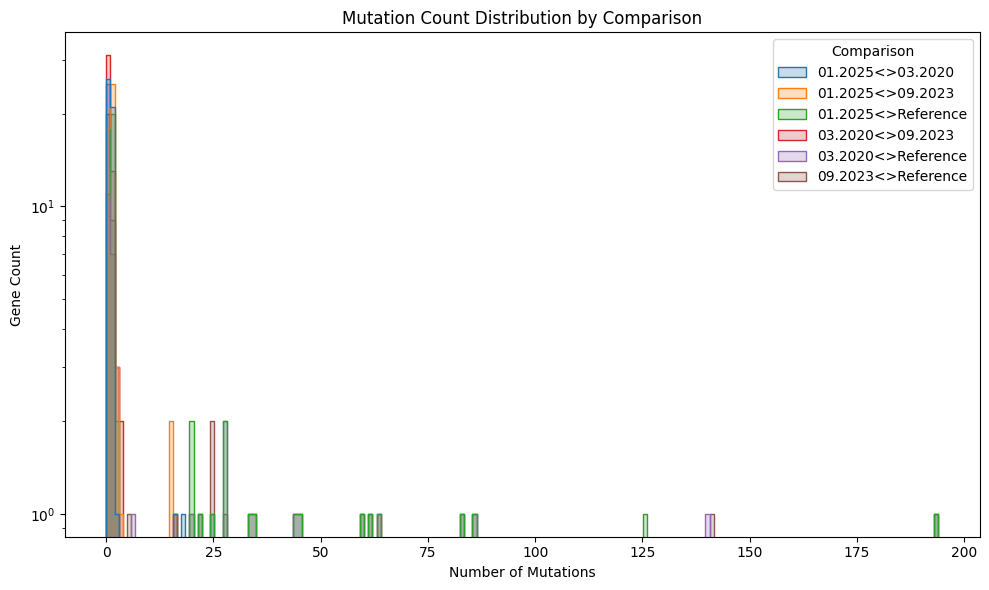

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

mutation_cols = [
    '01.2025<>03.2020',
    '01.2025<>09.2023',
    '01.2025<>Reference',
    '03.2020<>09.2023',
    '03.2020<>Reference',
    '09.2023<>Reference'
]

# Melt the dataframe to long format for seaborn
melted = most_variable_mutation_df[mutation_cols].melt(var_name='Comparison', value_name='Mutation Count')

plt.figure(figsize=(10, 6))
sns.histplot(data=melted, x='Mutation Count', hue='Comparison',  element='step', stat='count', bins=200, common_norm=False)
plt.title('Mutation Count Distribution by Comparison')
plt.xlabel('Number of Mutations')
plt.ylabel('Gene Count')
plt.yscale('log')
# plt.legend(title='Comparison', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
